# EDA Maintenance Prédictive Industrielle

Analyse exploratoire du dataset `industrial_machine_maintenance.csv`.
Objectif : comprendre les distributions, détecter les anomalies et quantifier le déséquilibre des classes avant modélisation.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import DATA_PATH, FEATURES_NUM, FEATURES_CAT, TARGET

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


## 1. Vue générale

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  str    
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  str    
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  str    
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  str    
 14  estimated_repair_cost    24042 no

In [3]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


## 2. Valeurs manquantes

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"count": missing, "pct": missing_pct}).loc[missing > 0]

,count,pct
vibration_rms,1000,4.16
pressure_level,924,3.84
temperature_motor,834,3.47
current_phase_avg,731,3.04
rpm,533,2.22


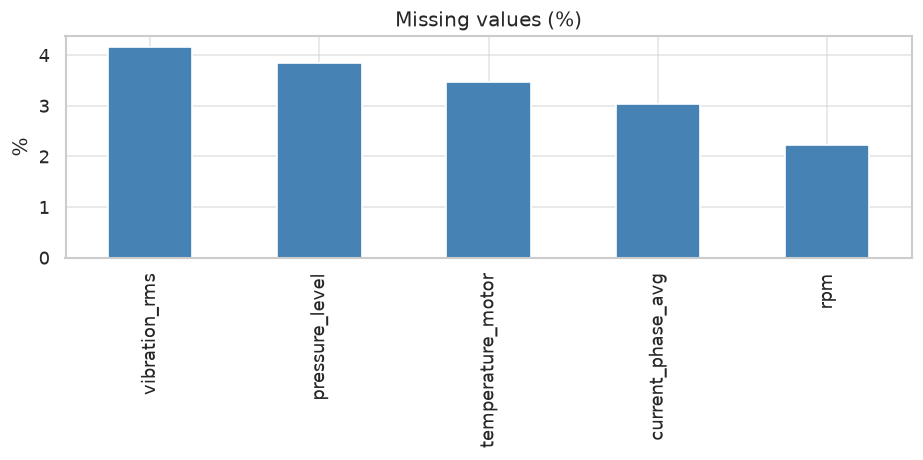

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Missing values (%)")
ax.set_ylabel("%")
plt.tight_layout()

## 3. Distribution de la variable cible : `failure_type`

                count    pct
failure_type                
none            20482  85.19
bearing          1117   4.65
motor_overheat   1060   4.41
hydraulic         728   3.03
electrical        655   2.72


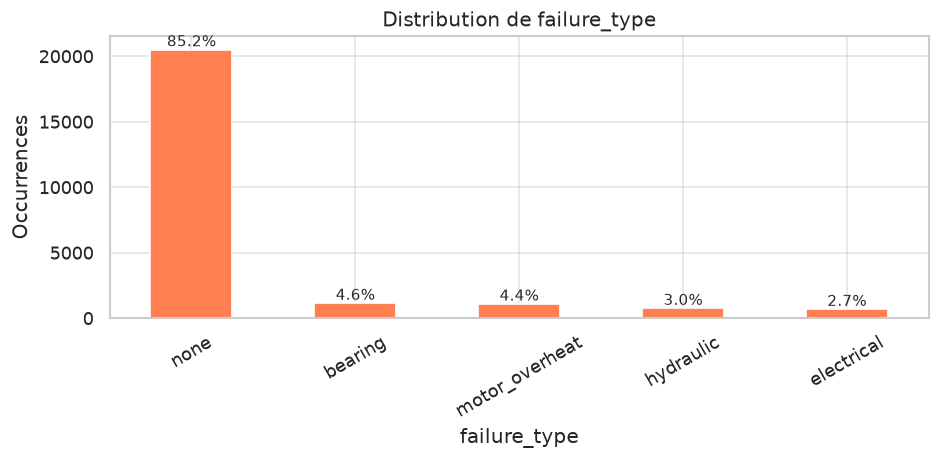

In [6]:
counts = df[TARGET].value_counts()
pct    = (counts / len(df) * 100).round(2)
print(pd.DataFrame({"count": counts, "pct": pct}))

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color="coral")
ax.set_title("Distribution de failure_type")
ax.set_ylabel("Occurrences")
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(df)*100:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()

## 4. Distributions des features numériques

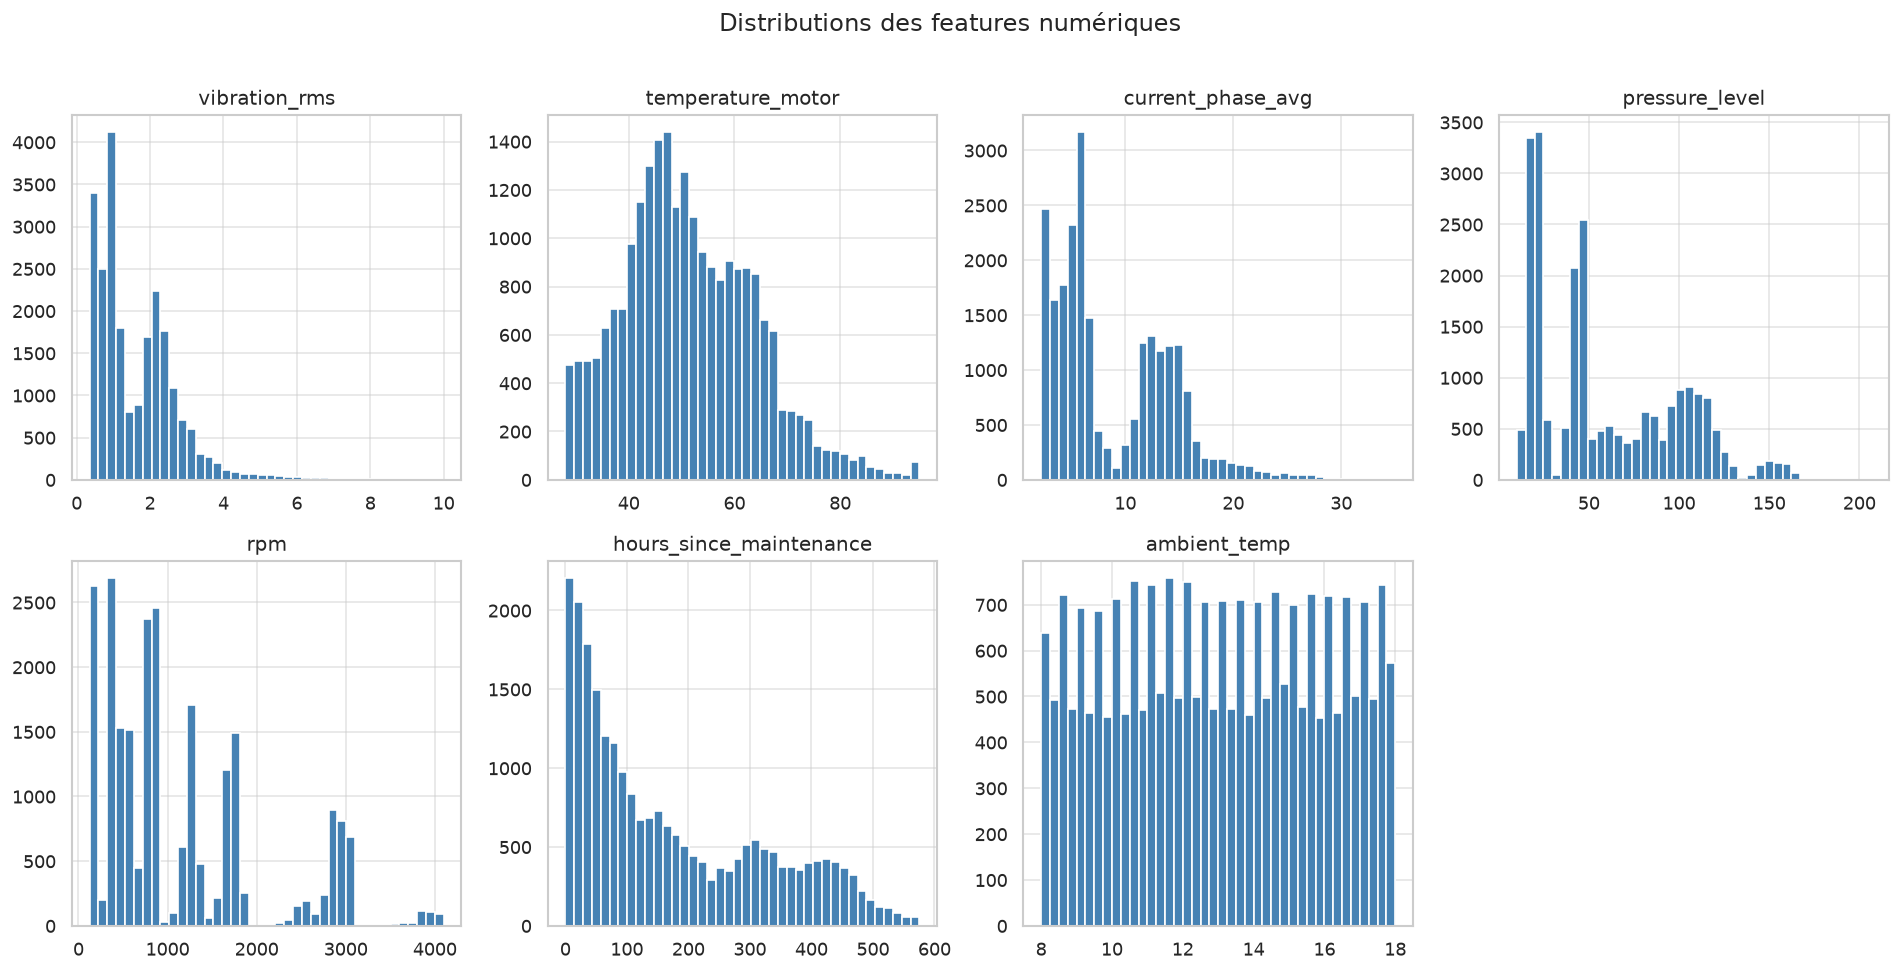

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, FEATURES_NUM):
    df[col].dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
axes.flat[-1].set_visible(False)
fig.suptitle("Distributions des features numériques", y=1.01)
plt.tight_layout()

## 5. Boxplots par type de défaillance

/tmp/ipykernel_55578/1586866328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, order=order, palette="Set2")
/tmp/ipykernel_55578/1586866328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, order=order, palette="Set2")
/tmp/ipykernel_55578/1586866328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, order=order, palette="Set2")
/tmp/ipykernel_55578/1586866328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

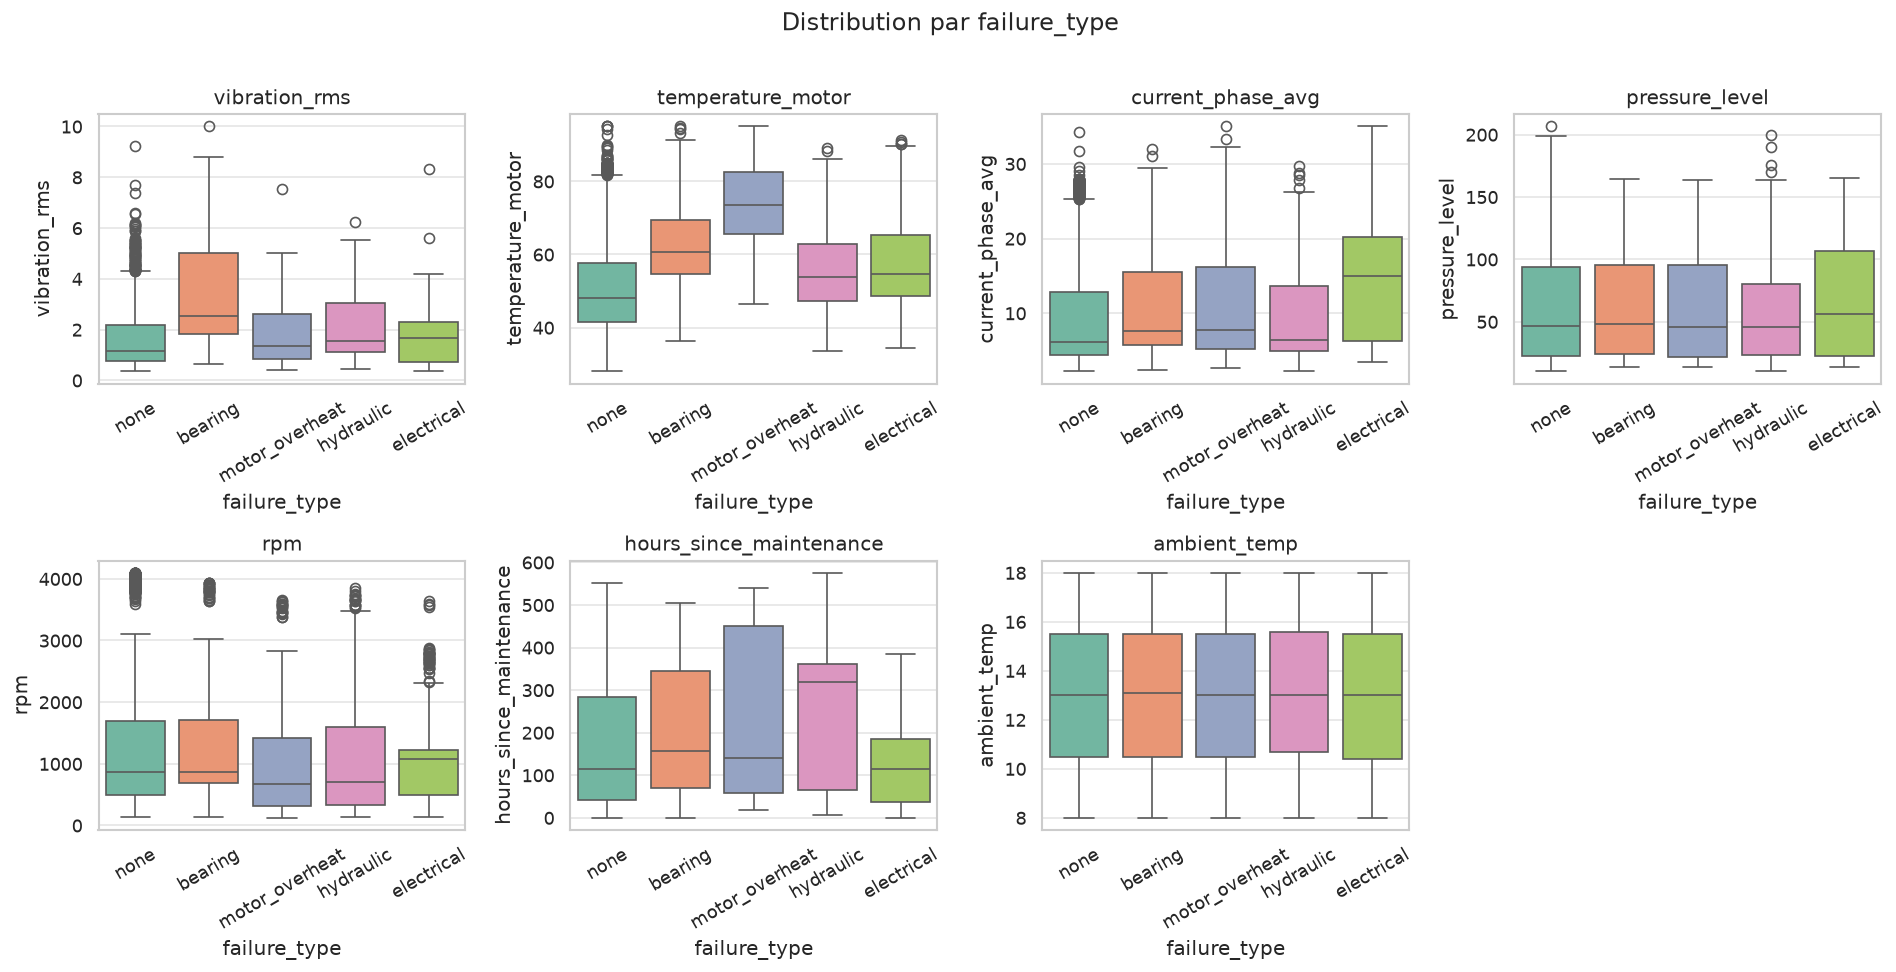

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
order = df[TARGET].value_counts().index
for ax, col in zip(axes.flat, FEATURES_NUM):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, order=order, palette="Set2")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
axes.flat[-1].set_visible(False)
fig.suptitle("Distribution par failure_type", y=1.01)
plt.tight_layout()

## 6. Matrice de corrélation

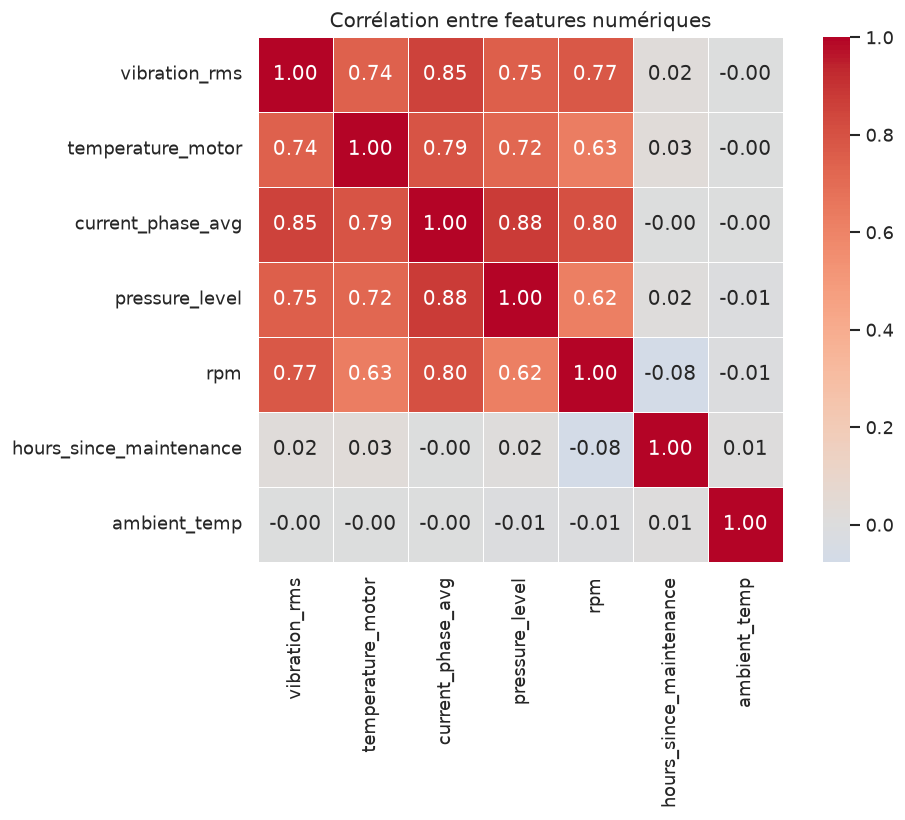

In [9]:
corr = df[FEATURES_NUM].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Corrélation entre features numériques")
plt.tight_layout()

## 7. Variables catégorielles

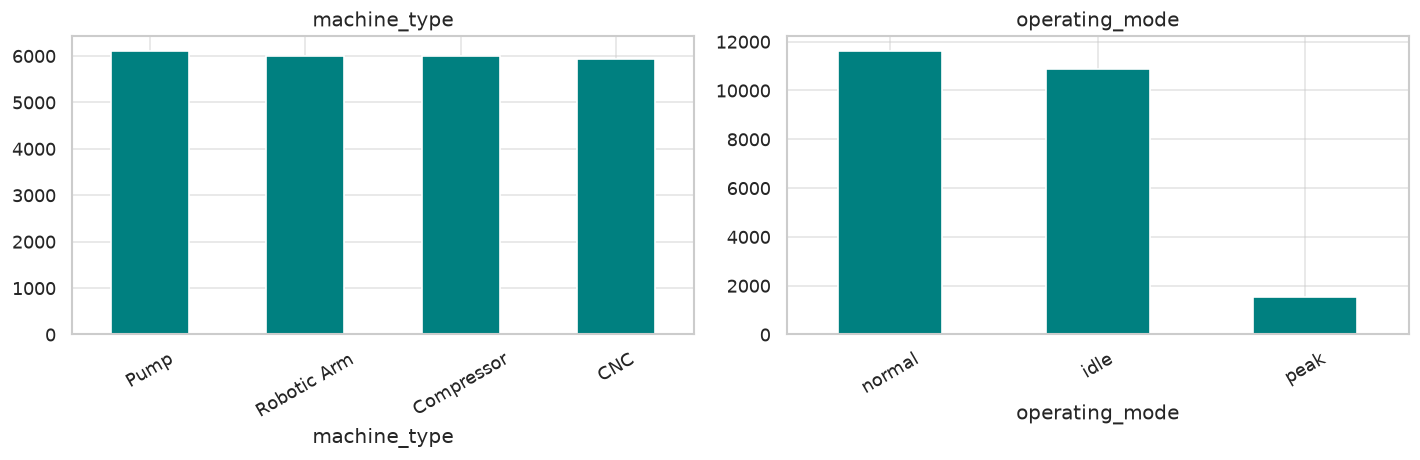

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, FEATURES_CAT):
    df[col].value_counts().plot(kind="bar", ax=ax, color="teal")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

## 8. Colonnes exclues (leakage)

| Colonne | Raison |
|---|---|
| `failure_within_24h` | Corrélé directement avec `failure_type` |
| `rul_hours` | Outcome prédit par le type de panne |
| `estimated_repair_cost` | Outcome post-panne |
| `timestamp`, `machine_id` | Identifiants non généralisables |

In [11]:
print("Corrélation failure_within_24h / failure_type :")
print(df.groupby(TARGET)["failure_within_24h"].mean())

Corrélation failure_within_24h / failure_type :
failure_type
bearing           1.0
electrical        1.0
hydraulic         1.0
motor_overheat    1.0
none              0.0
Name: failure_within_24h, dtype: float64


## 9. Conclusions

- **Déséquilibre sévère** : 85% `none`, ratio ~31:1 → SMOTE ou `class_weight="balanced"` obligatoire
- **Missing values** : 2–4% sur 5 colonnes → imputation médiane
- **Features discriminantes** : `vibration_rms`, `temperature_motor` montrent les plus grandes variations inter-classes
- **Métriques prioritaires** : Recall macro + F1 macro + ROC-AUC (accuracy insuffisante)